In [ ]:
# ============================================================
# CELL 1: INSTALL & IMPORT LIBRARY
# ============================================================
!pip install -q numpy pandas matplotlib scikit-learn
!pip install -q bayesian-optimization numpy matplotlib scikit-learn scikit-optimize pandas

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import warnings
import os
import sys
import json
import random
import subprocess
import time
import requests
import re
from sklearn.preprocessing import StandardScaler
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import RBF, WhiteKernel
from skopt import gp_minimize
from skopt.space import Real, Integer
from skopt.utils import use_named_args
from pathlib import Path
from collections import defaultdict
from typing import List, Dict, Tuple, Optional
from google.colab import files

warnings.filterwarnings('ignore')
print("✅ Semua library berhasil diimport!")


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 107.8/107.8 kB 7.3 MB/s eta 0:00:00
✅ Semua library berhasil diimport!


In [ ]:
# ============================================================
# CELL 2: UPLOAD FILE (FLEKSIBEL)
# ============================================================

def upload_files():
    """
    Upload file CSV secara fleksibel.
    User bisa upload 1 atau 2 file dengan nama apapun.
    """
    print("\n" + "="*70)
    print("📤 UPLOAD FILE DATA PENILAIAN")
    print("="*70)
    print("Upload file CSV yang Anda miliki:")
    print("  1. data_penilai_rata-rata.csv (data agregat per prompt)")
    print("  2. data_penilai_detail.csv (data detail per penilai)")
    print("\n💡 Tips: Anda bisa upload 1 atau 2 file sekaligus.")
    print("   Klik 'Choose Files' lalu pilih file yang diinginkan.")
    print("-"*70)

    uploaded = files.upload()

    if not uploaded:
        print("\n⚠️ Tidak ada file yang diupload!")
        print("📊 Sistem akan menggunakan data sintetik sebagai fallback.")
        return {}

    print(f"\n✅ {len(uploaded)} file berhasil diupload!")
    return uploaded

def detect_file_type(df, filename):
    """
    Deteksi tipe file berdasarkan struktur kolom.
    Returns: 'rata_rata', 'detail', atau 'unknown'
    """
    cols = set(df.columns)

    # Cek apakah ini file rata-rata (agregat)
    rata_rata_cols = {'kode_prompt', 'video', 'varian', 'rata_clarity',
                      'rata_structure', 'rata_creativity', 'rata_completeness', 'skor_total'}
    if rata_rata_cols.issubset(cols):
        return 'rata_rata'

    # Cek apakah ini file detail
    detail_cols = {'kode_prompt', 'video', 'varian', 'penilai',
                   'kategori_penilai', 'skor_clarity', 'skor_structure',
                   'skor_creativity', 'skor_completeness'}
    if detail_cols.issubset(cols):
        return 'detail'

    # Cek alternatif: jika ada kolom clarity, structure, dll tanpa prefix
    if {'clarity', 'structure', 'creativity', 'completeness'}.issubset(cols):
        return 'rata_rata_simple'

    return 'unknown'

def load_uploaded_files(uploaded_files):
    """
    Proses file yang diupload dan simpan ke dictionary.
    """
    data_files = {
        'rata_rata': None,
        'detail': None,
        'other': []
    }

    print("\n" + "="*70)
    print("📊 MEMPROSES FILE UPLOAD")
    print("="*70)

    for filename, content in uploaded_files.items():
        try:
            # Baca file
            df = pd.read_csv(pd.io.common.BytesIO(content))
            print(f"\n📄 File: {filename}")
            print(f"   → {len(df)} baris, {len(df.columns)} kolom")
            print(f"   → Kolom: {list(df.columns)}")

            # Deteksi tipe file
            file_type = detect_file_type(df, filename)

            if file_type == 'rata_rata':
                data_files['rata_rata'] = df
                print(f"   ✅ Dikenali sebagai: DATA RATA-RATA (agregat)")
            elif file_type == 'detail':
                data_files['detail'] = df
                print(f"   ✅ Dikenali sebagai: DATA DETAIL (per penilai)")
            elif file_type == 'rata_rata_simple':
                # Rename kolom untuk konsistensi
                rename_map = {
                    'clarity': 'rata_clarity',
                    'structure': 'rata_structure',
                    'creativity': 'rata_creativity',
                    'completeness': 'rata_completeness'
                }
                df = df.rename(columns=rename_map)
                # Tambahkan skor_total jika tidak ada
                if 'skor_total' not in df.columns:
                    df['skor_total'] = df[['rata_clarity', 'rata_structure',
                                           'rata_creativity', 'rata_completeness']].mean(axis=1)
                data_files['rata_rata'] = df
                print(f"   ✅ Dikenali sebagai: DATA RATA-RATA (simple format)")
            else:
                data_files['other'].append((filename, df))
                print(f"   ⚠️ Format tidak dikenali, disimpan sebagai 'other'")

        except Exception as e:
            print(f"   ❌ Error membaca {filename}: {str(e)}")

    return data_files

# ============================================================
# CELL 3: PROSES DATA UNTUK TRAINING
# ============================================================

def prepare_training_data(data_files):
    """
    Siapkan data training untuk Weighted_Linear_Regression dari file yang diupload.
    🔥 PRIORITAS: DETAIL (3.360 baris) > AGREGAT (160 baris)
    """
    print("\n" + "="*70)
    print("🔧 MEMPERSIAPKAN DATA TRAINING")
    print("="*70)

    # === PRIORITAS 1: DATA DETAIL (3.360 baris) ===
    if data_files['detail'] is not None:
        df = data_files['detail'].copy()
        print("\n✅ PRIORITAS 1: Menggunakan DATA DETAIL (per penilai).")
        print(f"   → {len(df)} data poin")

        # Format untuk Weighted_Linear_Regression
        df_train = pd.DataFrame({
            'clarity': df['skor_clarity'],
            'structure': df['skor_structure'],
            'creativity': df['skor_creativity'],
            'completeness': df['skor_completeness'],
            'skor': df[['skor_clarity', 'skor_structure',
                        'skor_creativity', 'skor_completeness']].mean(axis=1)
        })

        print(f"   → {len(df_train)} data poin siap untuk training")
        print(f"   → Skor rata-rata: {df_train['skor'].mean():.2f}")
        print(f"   → Skor min: {df_train['skor'].min():.2f}")
        print(f"   → Skor max: {df_train['skor'].max():.2f}")
        print(f"   → Std dev: {df_train['skor'].std():.2f}")

        # Tampilkan distribusi penilai
        if 'kategori_penilai' in df.columns:
            print(f"\n   📊 Distribusi penilai:")
            for kategori, count in df['kategori_penilai'].value_counts().items():
                print(f"      - {kategori}: {count} penilaian")

        return df_train

    # === PRIORITAS 2: DATA AGREGAT (160 baris) ===
    if data_files['rata_rata'] is not None:
        df = data_files['rata_rata'].copy()
        print("\n⚠️ DATA DETAIL tidak tersedia.")
        print("✅ PRIORITAS 2: Menggunakan DATA AGREGAT (rata-rata).")

        df_train = pd.DataFrame({
            'clarity': df['rata_clarity'],
            'structure': df['rata_structure'],
            'creativity': df['rata_creativity'],
            'completeness': df['rata_completeness'],
            'skor': df['skor_total']
        })
        print(f"   → {len(df_train)} data poin siap untuk training")
        return df_train

    # === PRIORITAS 3: DATA SINTETIK ===
    print("\n⚠️ Tidak ada data training yang valid!")
    print("📊 Membuat DATA SINTETIK sebagai fallback...")

    np.random.seed(42)
    n_samples = 200
    data = []
    for i in range(n_samples):
        base = np.random.uniform(5.5, 8.5)
        clarity = np.clip(base + np.random.normal(0, 0.8), 1, 10)
        structure = np.clip(base + np.random.normal(0, 0.8), 1, 10)
        creativity = np.clip(base + np.random.normal(0, 1.0), 1, 10)
        completeness = np.clip(base + np.random.normal(0, 0.8), 1, 10)
        skor = np.mean([clarity, structure, creativity, completeness])
        skor = np.clip(skor + np.random.normal(0, 0.3), 1, 10)
        data.append({
            'clarity': clarity,
            'structure': structure,
            'creativity': creativity,
            'completeness': completeness,
            'skor': skor
        })

    df_train = pd.DataFrame(data)
    print(f"   → {len(df_train)} data poin sintetik dibuat")
    return df_train


In [ ]:
# ============================================================
# FUNGSI SETUP_OLLAMA() - VERSI GABUNGAN TERBAIK
# ============================================================

def setup_ollama(force_register=True, timeout=120, verbose=True):
    """
    Setup Ollama lengkap dengan:
    1. Install dependencies (zstd)
    2. Install Ollama binary (jika belum)
    3. Cek model di Drive (TIDAK DOWNLOAD ULANG jika sudah ada)
    4. Start server di background
    5. Force register model dari Drive (opsional)
    6. Test generate untuk verifikasi

    Args:
        force_register: Boolean, apakah force register model (default: True)
        timeout: Timeout untuk test generate (default: 120 detik)
        verbose: Boolean, tampilkan output detail (default: True)

    Returns:
        bool: True jika sukses, False jika gagal
    """

    if verbose:
        print("="*70)
        print("🚀 SETUP OLLAMA")
        print("="*70)

    # === STEP 1: Setup environment ===
    if verbose:
        print("\n[1] Setting up environment...")
    os.environ['OLLAMA_MODELS'] = '/content/drive/MyDrive/ollama/models'
    os.environ['OLLAMA_HOST'] = '127.0.0.1:11434'
    if verbose:
        print("   ✅ Environment set!")

    # === STEP 2: Install dependencies ===
    if verbose:
        print("\n[2] Installing dependencies...")
    !sudo apt-get update -qq
    !sudo apt-get install -y zstd -qq
    if verbose:
        print("   ✅ zstd installed!")

    # === STEP 3: Install Ollama binary (hanya jika belum) ===
    if verbose:
        print("\n[3] Checking Ollama binary...")

    # Cek apakah ollama sudah terinstall
    result = subprocess.run(['which', 'ollama'], capture_output=True, text=True)
    if result.returncode == 0:
        if verbose:
            print(f"   ✅ Ollama already installed: {result.stdout.strip()}")
    else:
        if verbose:
            print("   📥 Installing Ollama binary...")
        !curl -fsSL https://ollama.com/install.sh | sh
        if verbose:
            print("   ✅ Ollama installed!")

    # === STEP 4: Cek Drive ===
    if verbose:
        print("\n[4] Checking Google Drive...")
    if os.path.exists('/content/drive/MyDrive'):
        if verbose:
            print("   ✅ Drive already mounted!")
    else:
        if verbose:
            print("   📤 Mounting Drive...")
        from google.colab import drive
        drive.mount('/content/drive')

    # === STEP 5: Cek model di Drive (TANPA DOWNLOAD ULANG) ===
    if verbose:
        print("\n[5] Checking model in Drive...")

    OLLAMA_MODELS_PATH = '/content/drive/MyDrive/ollama/models'

    # Cek apakah folder models ada dan berisi file
    if os.path.exists(OLLAMA_MODELS_PATH):
        files = os.listdir(OLLAMA_MODELS_PATH)
        if verbose:
            print(f"   📁 Models path: {OLLAMA_MODELS_PATH}")
            print(f"   📁 Contents: {files}")

        # Cek apakah ada file model (blobs)
        blobs_path = f'{OLLAMA_MODELS_PATH}/blobs'
        if os.path.exists(blobs_path):
            blobs = os.listdir(blobs_path)
            if len(blobs) > 0:
                if verbose:
                    print(f"   ✅ Model files found in Drive! ({len(blobs)} blobs)")
                    print(f"   💡 Tidak perlu download ulang!")
            else:
                if verbose:
                    print("   ⚠️ Models folder exists but empty")
        else:
            if verbose:
                print("   ⚠️ No blobs folder found")
    else:
        if verbose:
            print(f"   ⚠️ Models folder not found: {OLLAMA_MODELS_PATH}")
            print("   📥 Akan download model jika diperlukan")

    # === STEP 6: Kill existing server ===
    if verbose:
        print("\n[6] Killing existing server...")
    !pkill ollama 2>/dev/null || true
    time.sleep(2)
    if verbose:
        print("   ✅ Done!")

    # === STEP 7: Start server ===
    if verbose:
        print("\n[7] Starting Ollama server...")
    !nohup ollama serve > /tmp/ollama.log 2>&1 &
    time.sleep(8)
    if verbose:
        print("   ✅ Server started!")

    # === STEP 8: Cek model di Ollama ===
    if verbose:
        print("\n[8] Checking models in Ollama...")
    result = subprocess.run(['ollama', 'list'], capture_output=True, text=True)
    if verbose:
        print(f"   {result.stdout.strip() if result.stdout else '(empty)'}")

    # === STEP 9: Register model (jika perlu) ===
    if force_register or 'mistral' not in result.stdout:
        if verbose:
            print("\n[9] Registering model from Drive...")

        # 🔥 KRITICAL: Pull akan VERIFIKASI file yang sudah ada, TIDAK DOWNLOAD ULANG
        if verbose:
            print("   📥 Running 'ollama pull mistral' (akan verifikasi file existing)...")

        result = subprocess.run(['ollama', 'pull', 'mistral'], capture_output=True, text=True)

        if verbose:
            if 'already' in result.stdout.lower() or 'exists' in result.stdout.lower():
                print("   ✅ Model already exists (verified!)")
            elif 'downloading' in result.stdout.lower():
                print("   ⚠️ Model downloading... (ini terjadi jika belum ada)")
            else:
                print(f"   {result.stdout[:200] if result.stdout else 'Done'}")

        # Cek lagi
        result = subprocess.run(['ollama', 'list'], capture_output=True, text=True)
        if 'mistral' in result.stdout:
            if verbose:
                print("   ✅ Model registered successfully!")
        else:
            if verbose:
                print("   ⚠️ Still not registered. Trying force pull...")
            subprocess.run(['ollama', 'pull', 'mistral', '--force'])
    else:
        if verbose:
            print("\n[9] ✅ Model already registered (no action needed)")

    # === STEP 10: Verifikasi API ===
    if verbose:
        print("\n[10] Verifying API...")
    try:
        response = requests.get('http://127.0.0.1:11434/api/tags', timeout=5)
        if response.status_code == 200:
            if verbose:
                print(f"   ✅ API OK!")
                print(f"   Models: {response.json()}")
        else:
            if verbose:
                print(f"   ⚠️ API response: {response.status_code}")
    except Exception as e:
        if verbose:
            print(f"   ❌ API error: {e}")
        return False

    # === STEP 11: Test generate ===
    if verbose:
        print("\n[11] Testing generate...")
    try:
        response = requests.post(
            'http://127.0.0.1:11434/api/generate',
            json={
                "model": "mistral",
                "prompt": "Sebutkan 1 manfaat belajar.",
                "stream": False,
                "options": {"num_predict": 50}
            },
            timeout=timeout
        )

        if response.status_code == 200:
            output = response.json().get('response', '')
            if verbose:
                print(f"   ✅ SUCCESS! Response: {output[:100]}...")
            else:
                # Silent mode - just return True
                pass
        else:
            if verbose:
                print(f"   ❌ Error: {response.status_code} - {response.text[:200]}")
            return False
    except Exception as e:
        if verbose:
            print(f"   ❌ Error: {e}")
        return False

    if verbose:
        print("\n" + "="*70)
        print("✅ OLLAMA SETUP COMPLETE!")
        print("="*70)

    return True


def start_ollama_quick():
    """
    Start Ollama cepat (tanpa force register) - untuk session yang sudah ada model.
    Hanya install binary dan start server.
    """
    print("🚀 Starting Ollama (quick mode)...")

    # Set environment
    os.environ['OLLAMA_MODELS'] = '/content/drive/MyDrive/ollama/models'
    os.environ['OLLAMA_HOST'] = '127.0.0.1:11434'

    # Install dependencies
    !sudo apt-get update -qq
    !sudo apt-get install -y zstd -qq

    # Cek apakah ollama sudah terinstall
    result = subprocess.run(['which', 'ollama'], capture_output=True, text=True)
    if result.returncode != 0:
        !curl -fsSL https://ollama.com/install.sh | sh

    # Start server
    !pkill ollama 2>/dev/null || true
    !nohup ollama serve > /tmp/ollama.log 2>&1 &

    time.sleep(5)
    print("✅ Ollama started!")

    # Verifikasi cepat
    try:
        response = requests.get('http://127.0.0.1:11434/api/tags', timeout=3)
        if response.status_code == 200:
            print(f"   ✅ Server running! Models: {response.json()}")
            return True
        else:
            print(f"   ⚠️ Server response: {response.status_code}")
            return False
    except:
        print("   ⚠️ Server not ready yet (normal, tunggu beberapa detik)")
        return False


def is_ollama_ready():
    """
    Cek apakah Ollama sudah siap digunakan.
    Returns: bool
    """
    try:
        response = requests.get('http://127.0.0.1:11434/api/tags', timeout=3)
        if response.status_code == 200:
            models = response.json().get('models', [])
            for m in models:
                if m.get('name', '').startswith('mistral'):
                    return True
        return False
    except:
        return False

In [ ]:
# ============================================================
# CELL 4: DATA SUBMATERI (32 TOPIK)
# ============================================================

SUBMATERI_LIST = [
    # ========== LITERASI (17) ==========
    {"nama": "Pengenalan Teks Deskripsi", "keyword": ["pengertian", "ciri", "tujuan", "deskripsi"]},
    {"nama": "Struktur Teks Deskripsi", "keyword": ["identifikasi", "klasifikasi", "deskripsi bagian"]},
    {"nama": "Kaidah Kebahasaan Teks Deskripsi", "keyword": ["kata benda", "kata sifat", "kata kerja", "frasa"]},
    {"nama": "Pengenalan Poster", "keyword": ["pengertian", "tujuan", "fungsi", "poster"]},
    {"nama": "Jenis-Jenis Poster", "keyword": ["niaga", "layanan masyarakat", "pendidikan"]},
    {"nama": "Unsur-Unsur Poster", "keyword": ["teks", "gambar", "warna", "layout"]},
    {"nama": "Pengenalan Teks Berita", "keyword": ["pengertian", "5w+1h", "berita"]},
    {"nama": "Struktur Teks Berita", "keyword": ["orientasi", "peristiwa", "sumber"]},
    {"nama": "Kaidah Kebahasaan Teks Berita", "keyword": ["bahasa baku", "kalimat langsung", "konjungsi"]},
    {"nama": "Pengenalan Cerpen", "keyword": ["pengertian", "ciri", "cerpen"]},
    {"nama": "Struktur Cerpen", "keyword": ["abstrak", "orientasi", "komplikasi", "resolusi", "koda"]},
    {"nama": "Unsur-Unsur Cerpen", "keyword": ["tema", "tokoh", "latar", "alur", "amanat"]},
    {"nama": "Kaidah Kebahasaan Cerpen", "keyword": ["majas", "dialog", "kata ganti"]},
    {"nama": "Pengenalan Teks Prosedur", "keyword": ["pengertian", "tujuan", "ciri"]},
    {"nama": "Struktur Teks Prosedur", "keyword": ["tujuan", "langkah", "penegasan"]},
    {"nama": "Kaidah Kebahasaan Teks Prosedur", "keyword": ["konjungsi temporal", "kata perintah"]},
    {"nama": "Jenis-Jenis Teks Prosedur", "keyword": ["protokol", "kompleks", "tips"]},
    # ========== NUMERASI (15) ==========
    {"nama": "Pengenalan Statistika", "keyword": ["pengertian", "statistika", "data"]},
    {"nama": "Statistika Deskriptif Bag.1", "keyword": ["mean", "median", "modus", "data tunggal"]},
    {"nama": "Statistika Deskriptif Bag.2", "keyword": ["tabel distribusi", "mean berkelompok", "median berkelompok"]},
    {"nama": "Probabilitas Bag.1", "keyword": ["peluang", "probabilitas", "kejadian", "ruang sampel"]},
    {"nama": "Probabilitas Bag.2", "keyword": ["peluang bersyarat", "probabilitas", "kejadian majemuk"]},
    {"nama": "Keuntungan (Laba) dan Kerugian", "keyword": ["harga beli", "harga jual", "untung", "rugi", "persentase"]},
    {"nama": "Bunga dan Pajak", "keyword": ["bunga tunggal", "bunga majemuk", "pajak", "ppn"]},
    {"nama": "Bruto, Tara, dan Neto", "keyword": ["bruto", "tara", "neto", "berat"]},
    {"nama": "Segi Banyak", "keyword": ["segitiga", "segiempat", "segi banyak", "poligon"]},
    {"nama": "Lingkaran", "keyword": ["unsur lingkaran", "keliling", "luas", "jari-jari"]},
    {"nama": "Bangun Ruang", "keyword": ["kubus", "balok", "prisma", "limas", "tabung", "kerucut", "bola", "volume"]},
    {"nama": "Sistem Persamaan Linear Dua/Tiga Variabel", "keyword": ["spldv", "spltv", "substitusi", "eliminasi"]},
    {"nama": "Barisan dan Deret", "keyword": ["barisan aritmatika", "deret aritmatika", "geometri"]},
    {"nama": "Fungsi dalam Aljabar Bag.1", "keyword": ["fungsi linear", "fungsi kuadrat", "grafik", "domain"]},
    {"nama": "Fungsi dalam Aljabar Bag.2", "keyword": ["fungsi komposisi", "fungsi invers", "operasi fungsi"]}
]

print(f"✅ {len(SUBMATERI_LIST)} topik dimuat!")
print(f"   Literasi: 17 topik")
print(f"   Numerasi: {len(SUBMATERI_LIST) - 17} topik")


✅ 32 topik dimuat!
   Literasi: 17 topik
   Numerasi: 15 topik


In [ ]:
# ============================================================
# PART 3: OUTLINE GENERATOR
# ============================================================

def validate_and_fix_duration(text, max_duration=10, min_duration=5):
    """
    Validasi durasi dalam teks prompt. Jika melebihi, koreksi otomatis.
    """
    import re

    # Cari pola durasi (misal: "13 menit", "10 menit", "5 menit")
    durasi_patterns = [
        r'(\d+\.?\d*)\s*menit',
        r'durasi\s*(\d+\.?\d*)\s*menit',
        r'total durasi\s*(\d+\.?\d*)\s*menit'
    ]

    found_duration = None

    for pattern in durasi_patterns:
        matches = re.findall(pattern, text.lower())
        if matches:
            try:
                found_duration = float(matches[0])
                break
            except:
                pass

    if found_duration is None:
        # Tidak ada durasi yang ditemukan, tambahkan
        text = f"⚠️ DURASI: {max_duration} menit (MAKSIMAL {max_duration} MENIT)\n\n" + text
        return text

    if found_duration > max_duration:
        # 🔥 KOREKSI OTOMATIS: ganti durasi
        print(f"   ⚠️ Durasi {found_duration} menit > {max_duration} menit! Mengoreksi...")

        # Ganti semua angka durasi dengan yang sudah dikoreksi
        for pattern in durasi_patterns:
            text = re.sub(
                pattern,
                f"{max_duration} menit",
                text
            )

        # Tambahkan warning di awal
        text = f"⚠️ DURASI DIKOREKSI: {max_duration} menit (MAKSIMAL {max_duration} MENIT)\n\n" + text
        return text

    if found_duration < min_duration:
        print(f"   ⚠️ Durasi {found_duration} menit < {min_duration} menit! Mengoreksi...")

        for pattern in durasi_patterns:
            text = re.sub(
                pattern,
                f"{min_duration + 2} menit",
                text
            )

        text = f"⚠️ DURASI DIKOREKSI: {min_duration + 2} menit (MINIMAL {min_duration} MENIT)\n\n" + text
        return text

    return text

class OutlineGenerator:
    """Generate struktur video dari keyword."""

    def __init__(self):
        self.templates = {
            "pengertian": {"label": "Pengertian", "durasi": 1.5},
            "ciri": {"label": "Ciri-ciri", "durasi": 1.5},
            "tujuan": {"label": "Tujuan", "durasi": 1.5},
            "fungsi": {"label": "Fungsi", "durasi": 1.5},
            "struktur": {"label": "Struktur", "durasi": 2.0},
            "identifikasi": {"label": "Identifikasi", "durasi": 2.0},
            "klasifikasi": {"label": "Klasifikasi", "durasi": 2.0},
            "mean": {"label": "Mean (Rata-rata)", "durasi": 2.0},
            "median": {"label": "Median", "durasi": 2.0},
            "modus": {"label": "Modus", "durasi": 2.0},
            "peluang": {"label": "Peluang", "durasi": 2.0},
            "probabilitas": {"label": "Probabilitas", "durasi": 2.0},
            "spldv": {"label": "SPLDV", "durasi": 2.0},
            "spltv": {"label": "SPLTV", "durasi": 2.0},
            "volume": {"label": "Volume", "durasi": 1.5},
            "luas": {"label": "Luas", "durasi": 1.5},
            "keliling": {"label": "Keliling", "durasi": 1.5},
            "fungsi linear": {"label": "Fungsi Linear", "durasi": 2.0},
            "fungsi kuadrat": {"label": "Fungsi Kuadrat", "durasi": 2.0},
            "fungsi komposisi": {"label": "Fungsi Komposisi", "durasi": 2.0},
            "fungsi invers": {"label": "Fungsi Invers", "durasi": 2.0},
        }

    def generate(self, nama, keyword):
        outline = []
        durasi_list = []
        total_durasi = 0

        # Tambahkan Pengertian jika tidak ada
        if not any("pengertian" in kw.lower() for kw in keyword):
            outline.append("Pengertian")
            durasi_list.append(1.5)
            total_durasi += 1.5

        # Map keyword ke template
        for kw in keyword:
            kw_lower = kw.lower()
            matched = False
            for tk, td in self.templates.items():
                if tk in kw_lower or kw_lower in tk:
                    if td['label'] not in outline:
                        outline.append(td['label'])
                        durasi_list.append(td['durasi'])
                        total_durasi += td['durasi']
                        matched = True
                        break
            if not matched and kw.capitalize() not in outline:
                outline.append(kw.capitalize())
                durasi_list.append(1.5)
                total_durasi += 1.5

        # Tambahkan bagian standar
        for section, dur in [("Contoh Soal", 2.5), ("Latihan Soal", 2.0), ("Kesimpulan", 1.0)]:
            if section not in outline:
                outline.append(section)
                durasi_list.append(dur)
                total_durasi += dur

        return {
            "nama": nama,
            "keyword": keyword,
            "outline": outline,
            "durasi_list": durasi_list,
            "total_durasi": total_durasi
        }


In [ ]:
# ============================================================
# CLASS PROMPTGENERATOR - DENGAN FORMAT BAKU + PERINGATAN TEGAS
# ============================================================

class PromptGenerator:
    """
    Generate prompt dengan FORMAT BAKU dari template.
    Mengacu pada struktur: Latar Belakang → Materi Spesifik → Contoh Soal → Latihan → Kesimpulan
    """

    def __init__(self, use_ollama=True, max_duration=10, min_duration=5, verbose=True):
        self.use_ollama = use_ollama
        self.max_duration = max_duration
        self.min_duration = min_duration
        self.verbose = verbose

        # 🔥 FORMAT BAKU - STRUKTUR VIDEO
        self.format_baku = {
            "struktur": [
                "LATAR BELAKANG",
                "MATERI SPESIFIK",
                "CONTOH SOAL DAN PEMBAHASAN",
                "LATIHAN SOAL",
                "KESIMPULAN"
            ],
            "gaya": "peer educating (seperti menjelaskan ke teman sendiri)",
            "durasi_range": "5-10 menit"
        }

        self.fokus_list = [
            {"name": "Teori", "focus": "theory", "desc": "Fokus pada pemahaman konsep teoritis secara mendalam"},
            {"name": "Aplikasi", "focus": "practice", "desc": "Fokus pada aplikasi praktis dan contoh kehidupan nyata"},
            {"name": "Visual", "focus": "visual", "desc": "Fokus pada gambaran visual dan imajinatif"},
            {"name": "Interaktif", "focus": "interactive", "desc": "Fokus pada diskusi dan partisipasi aktif siswa"},
            {"name": "Analitis", "focus": "analytical", "desc": "Fokus pada analisis kritis dan evaluasi"}
        ]

        self.gaya_list = ["standar", "santai", "persuasif", "storytelling", "dinamis"]

        # 🔥 GAYA BAHASA
        self.gaya_map = {
            "standar": "gaya interaktif, tidak monoton, seperti menjelaskan ke teman sebaya. Gunakan bahasa yang hidup dan mudah dipahami.",
            "santai": "gaya santai dan akrab, seperti ngobrol santai dengan teman sekelas. Banyak menggunakan analogi dari kehidupan sehari-hari.",
            "persuasif": "gaya persuasif yang memotivasi siswa. Membangun antusiasme dan rasa ingin tahu sejak awal video.",
            "storytelling": "gaya bercerita. Mengemas materi dalam bentuk narasi cerita yang menarik dan kontekstual.",
            "dinamis": "gaya dinamis dengan variasi intonasi. Menggunakan pertanyaan-pertanyaan menantang untuk menjaga fokus siswa."
        }

        self.fokus_map = {
            "theory": "Fokus pada pemahaman konsep teoritis secara mendalam. Berikan penjelasan yang komprehensif tentang setiap konsep.",
            "practice": "Fokus pada aplikasi praktis. Berikan banyak contoh dan latihan yang relevan dengan kehidupan sehari-hari.",
            "visual": "Fokus pada gambaran visual yang jelas. Sering menggunakan metafora dan perumpamaan visual untuk menjelaskan konsep.",
            "interactive": "Fokus pada diskusi dan partisipasi aktif. Banyak pertanyaan retoris dan ajakan untuk berpartisipasi.",
            "analytical": "Fokus pada analisis kritis. Ajak siswa untuk membandingkan, mengevaluasi, dan mensintesis informasi."
        }

        self.stats = {
            'ollama_success': 0,
            'manual_fallback': 0,
            'total_generated': 0,
            'duration_fixed': 0
        }

    # ============================================================
    # 1. VALIDASI DURASI
    # ============================================================

    def validate_and_fix_duration(self, text):
        """Validasi durasi dalam teks. Jika melebihi/kurang, koreksi."""
        if not text:
            return text

        import re

        patterns = [
            r'DURASI TOTAL\s*:\s*(\d+\.?\d*)\s*menit',
            r'Durasi Total\s*:\s*(\d+\.?\d*)\s*menit',
            r'durasi\s*(\d+\.?\d*)\s*menit',
            r'(\d+\.?\d*)\s*menit'
        ]

        found_duration = None

        for pattern in patterns:
            matches = re.findall(pattern, text, re.IGNORECASE)
            if matches:
                try:
                    found_duration = float(matches[0])
                    break
                except:
                    pass

        if found_duration is None:
            return text

        if found_duration > self.max_duration:
            if self.verbose:
                print(f"\n   ⚠️ Durasi {found_duration:.1f} menit > {self.max_duration} menit! Mengoreksi...")
            for pattern in patterns:
                text = re.sub(pattern, f"{self.max_duration:.1f} menit", text, flags=re.IGNORECASE)
            self.stats['duration_fixed'] += 1

        elif found_duration < self.min_duration:
            if self.verbose:
                print(f"\n   ⚠️ Durasi {found_duration:.1f} menit < {self.min_duration} menit! Mengoreksi...")
            corrected = self.min_duration + 1.0
            for pattern in patterns:
                text = re.sub(pattern, f"{corrected:.1f} menit", text, flags=re.IGNORECASE)
            self.stats['duration_fixed'] += 1

        return text

    # ============================================================
    # 2. BUILD TEMPLATE FORMAT BAKU - DIPERBAIKI
    # ============================================================

    def build_template_instruction(self, nama, outline_data, fokus, gaya):
        """
        🔥 MEMBANGUN INSTRUKSI PROMPT DENGAN FORMAT BAKU.
        🔥 HASIL AKHIR: INSTRUKSI PROMPT, BUKAN SKRIP VIDEO!
        """
        outline = outline_data['outline']
        keyword = outline_data['keyword']
        kategori = "Literasi" if "Literasi" in outline_data.get('kategori', '') else "Numerasi"
        total_durasi = outline_data['total_durasi']

        # 🔥 FORMAT BAKU DARI PDF - LENGKAP
        template = f"""
⚠️ PERINGATAN PENTING (WAJIB DIPATUHI):
1. ANDA HARUS MEMBUAT INSTRUKSI PROMPT, BUKAN SKRIP VIDEO!
2. INSTRUKSI PROMPT ADALAH TEKS PERINTAH UNTUK AI VIDEO GENERATOR
3. JANGAN BUAT NASKAH DRAMA/ADEGAN/DIALOG!
4. GUNAKAN BAHASA INDONESIA! DILARANG BAHASA INGGRIS!
5. WAJIB ADA BAGIAN "CONTOH SOAL DAN PEMBAHASAN"
6. WAJIB ADA BAGIAN "LATIHAN SOAL"
7. DURASI TOTAL WAJIB {self.min_duration}-{self.max_duration} MENIT!

================================================================
FORMAT BAKU YANG HARUS DIHASILKAN:
================================================================
Saya sedang membuat skrip untuk video materi pembelajaran {kategori} dengan subBab "{nama}".

Buatkan penjelasan tentang {nama} secara jelas, tetapi gaya bahasanya {self.gaya_map.get(gaya, self.gaya_map['standar'])}, serta penyampaiannya layaknya kamu menjelaskan ke temanmu sendiri.

DURASI TOTAL: {total_durasi:.1f} menit (WAJIB {self.min_duration}-{self.max_duration} menit)

STRUKTUR VIDEO:

LATAR BELAKANG ({min(1.5, total_durasi * 0.15):.1f} menit)
Buat hook yang menarik (15-30 detik pertama) dengan pertanyaan atau analogi yang relatable. Jelaskan mengapa topik ini penting dan relevan dengan kehidupan sehari-hari siswa.

MATERI SPESIFIK 1 ({total_durasi * 0.25:.1f} menit)
Jelaskan konsep dasar {nama} secara mendalam.
"""

        # 🔥 TAMBAHKAN SUBTOPIK DARI OUTLINE
        subtopik = [b for b in outline if b.lower() not in ['pengertian', 'contoh soal', 'latihan soal', 'kesimpulan']]
        if not subtopik:
            subtopik = [nama]

        for i, sub in enumerate(subtopik[:3], 1):
            durasi_sub = total_durasi * 0.12
            template += f"""
a. {sub} ({durasi_sub:.1f} menit):
Jelaskan {sub} dengan detail. Berikan contoh konkret dan analogi yang mudah dipahami.
"""

        template += f"""
MATERI SPESIFIK 2 ({total_durasi * 0.2:.1f} menit)
Jelaskan aspek penting lainnya dari {nama}.
"""

        for i, sub in enumerate(subtopik[3:5], 1):
            durasi_sub = total_durasi * 0.1
            template += f"""
a. {sub} ({durasi_sub:.1f} menit):
Jelaskan {sub} dengan contoh yang relevan.
"""

        template += f"""
CONTOH SOAL DAN PEMBAHASAN ({total_durasi * 0.15:.1f} menit)
Buat 2 contoh soal tentang {nama} dengan masing-masing soal menyajikan suatu kutipan teks/data secara utuh layaknya soal-soal {kategori}. Sertakan pembahasan untuk setiap soal.

LATIHAN SOAL ({total_durasi * 0.13:.1f} menit)
Buat 5 latihan soal tentang {nama} dengan masing-masing soal menyajikan suatu kutipan teks/data secara utuh. Jangan sertakan pembahasan.

KESIMPULAN ({total_durasi * 0.1:.1f} menit)
Ringkasan poin-poin penting dari {nama} secara singkat per point (point 1-4).
================================================================

FOKUS: {self.fokus_map.get(fokus, self.fokus_map['theory'])}
GAYA: {self.gaya_map.get(gaya, self.gaya_map['standar'])}

🔥 INGAT: HASIL AKHIR HARUS BERUPA INSTRUKSI PROMPT, BUKAN SKRIP VIDEO!
🔥 GUNAKAN BAHASA INDONESIA!
🔥 WAJIB ADA CONTOH SOAL DAN LATIHAN SOAL!
"""
        return template

    # ============================================================
    # 3. OLLAMA GENERATE (STREAMING) - SAMA
    # ============================================================

    def generate_with_ollama_streaming(self, prompt_instruction, timeout=300):
        """Generate menggunakan Ollama API dengan STREAMING."""
        import os
        import requests
        import json
        import sys

        os.environ['OLLAMA_MODELS'] = '/content/drive/MyDrive/ollama/models'
        os.environ['OLLAMA_HOST'] = '127.0.0.1:11434'

        url = "http://127.0.0.1:11434/api/generate"
        payload = {
            "model": "mistral",
            "prompt": prompt_instruction,
            "stream": True,
            "options": {
                "temperature": 0.7,
                "num_predict": 1024
            }
        }

        if self.verbose:
            print("\n   📝 [OLLAMA] Streaming response:", end=" ")
            sys.stdout.flush()

        try:
            response = requests.post(url, json=payload, stream=True, timeout=timeout)

            if response.status_code != 200:
                if self.verbose:
                    print(f"\n   ❌ API error: {response.status_code}")
                return None

            full_response = ""
            chunk_count = 0

            for line in response.iter_lines():
                if line:
                    try:
                        data = json.loads(line)
                        chunk = data.get('response', '')
                        if chunk:
                            full_response += chunk
                            chunk_count += 1
                            if self.verbose:
                                print(chunk, end='', flush=True)
                            if data.get('done', False):
                                break
                    except:
                        pass

            if self.verbose:
                print()

            if len(full_response) > 50:
                if self.verbose:
                    print(f"   ✅ [OLLAMA] Success! ({len(full_response)} chars, {chunk_count} chunks)")
                return full_response
            else:
                if self.verbose:
                    print(f"   ⚠️ [OLLAMA] Response too short: {len(full_response)} chars")
                return None

        except requests.exceptions.Timeout:
            if self.verbose:
                print(f"\n   ❌ [OLLAMA] Timeout after {timeout}s")
            return None
        except Exception as e:
            if self.verbose:
                print(f"\n   ❌ [OLLAMA] Error: {e}")
            return None

    # ============================================================
    # 4. MANUAL GENERATE - DIPERBAIKI
    # ============================================================

    def generate_prompt_manual(self, nama, outline_data, fokus, gaya, iteration):
        """Generate 1 prompt secara manual dengan FORMAT BAKU."""
        import time

        if self.verbose:
            print(f"\n   📝 [MANUAL] Generating...", end=" ")
            sys.stdout.flush()

        # 🔥 Gunakan template format baku
        prompt = self.build_template_instruction(nama, outline_data, fokus, gaya)

        # 🔥 Validasi durasi
        prompt = self.validate_and_fix_duration(prompt)

        if self.verbose:
            print("\n   📝 [MANUAL] Streaming output:")
            print("   " + "-" * 50)
            for char in prompt[:200]:
                print(char, end='', flush=True)
                time.sleep(0.002)
            if len(prompt) > 200:
                print(f"... ({len(prompt) - 200} chars more)")
            print("\n   " + "-" * 50)
            print(f"   ✅ [MANUAL] Success! ({len(prompt)} chars)")

        return prompt

    # ============================================================
    # 5. GENERATE VARIAN - DIPERBAIKI
    # ============================================================

    def generate_variants(self, nama, outline_data, n_variants=30, use_ollama=None):
        """Generate n varian prompt dengan FORMAT BAKU."""
        if use_ollama is None:
            use_ollama = self.use_ollama

        variants = []

        self.stats = {
            'ollama_success': 0,
            'manual_fallback': 0,
            'total_generated': 0,
            'duration_fixed': 0
        }

        # Buat kombinasi
        combinations = []
        for f in self.fokus_list:
            for g in self.gaya_list:
                combinations.append((f, g))

        while len(combinations) < n_variants:
            combinations.extend(combinations[:n_variants - len(combinations)])

        print("\n" + "="*60)
        print(f"📝 GENERATING {n_variants} PROMPT VARIANTS")
        print(f"   Mode: {'Ollama' if use_ollama else 'Manual'}")
        print(f"   Format: BAKU (Latar Belakang → Materi → Contoh → Latihan → Kesimpulan)")
        print(f"   Durasi: {self.min_duration}-{self.max_duration} menit")
        print("="*60)

        for i, (fokus, gaya) in enumerate(combinations[:n_variants], 1):
            print(f"\n[{i}/{n_variants}] {fokus['name']} | {gaya}", end=" ")

            if use_ollama:
                # 🔥 PROMPT INSTRUKSI UNTUK OLLAMA
                template_instruction = self.build_template_instruction(nama, outline_data, fokus['focus'], gaya)

                ollama_prompt = f"""
⚠️ PERINGATAN: ANDA HARUS MEMBUAT INSTRUKSI PROMPT, BUKAN SKRIP VIDEO!
⚠️ GUNAKAN BAHASA INDONESIA! DILARANG BAHASA INGRIS!
⚠️ WAJIB ADA CONTOH SOAL DAN LATIHAN SOAL!

{template_instruction}

🔥 INGAT: HASIL AKHIR HARUS BERUPA INSTRUKSI PROMPT, BUKAN SKRIP VIDEO!
"""

                response = self.generate_with_ollama_streaming(ollama_prompt, timeout=300)

                if response and len(response) > 50:
                    response = self.validate_and_fix_duration(response)
                    text = response
                    self.stats['ollama_success'] += 1
                    if self.verbose:
                        print(f"   ✅ [OLLAMA] Success! ({len(text)} chars)")
                else:
                    if self.verbose:
                        print(f"\n   ⚠️ [OLLAMA] Failed, using manual...")
                    text = self.generate_prompt_manual(nama, outline_data, fokus['focus'], gaya, i)
                    self.stats['manual_fallback'] += 1
            else:
                text = self.generate_prompt_manual(nama, outline_data, fokus['focus'], gaya, i)
                self.stats['manual_fallback'] += 1

            variants.append({
                'name': f"Varian {i}",
                'fokus': fokus['name'],
                'fokus_key': fokus['focus'],
                'gaya': gaya,
                'text': text
            })

            self.stats['total_generated'] += 1

            if i % 10 == 0:
                print(f"\n   📊 PROGRESS: {i}/{n_variants}")
                print(f"      Ollama: {self.stats['ollama_success']}, Manual: {self.stats['manual_fallback']}")

        print("\n" + "="*60)
        print("✅ GENERATION COMPLETE!")
        print(f"   Total: {self.stats['total_generated']} variants")
        print(f"   Ollama success: {self.stats['ollama_success']}/{n_variants}")
        print(f"   Manual fallback: {self.stats['manual_fallback']}/{n_variants}")
        print(f"   Durasi dikoreksi: {self.stats['duration_fixed']}")
        print("="*60)

        return variants

    # ============================================================
    # 6. HELPER
    # ============================================================

    def get_stats(self):
        return self.stats

    def reset_stats(self):
        self.stats = {
            'ollama_success': 0,
            'manual_fallback': 0,
            'total_generated': 0,
            'duration_fixed': 0
        }

In [ ]:
# ============================================================
# PART 5: FEATURE EXTRACTOR (CSCC)
# ============================================================

class FeatureExtractor:
    """Ekstrak 4 fitur CSCC dari teks prompt."""

    def extract(self, text, nama):
        """Ekstrak (clarity, structure, creativity, completeness) skala 1-10."""
        text_lower = text.lower()

        # === CLARITY ===
        clarity = 5.0
        structural_kw = ['pengertian', 'ciri', 'tujuan', 'contoh', 'kesimpulan', 'latihan']
        for kw in structural_kw:
            if kw in text_lower:
                clarity += 0.4
        question_words = ['apa', 'bagaimana', 'mengapa', 'kapan', '?']
        for q in question_words:
            if q in text_lower:
                clarity += 0.2
        clarity = np.clip(clarity, 1, 10)

        # === STRUCTURE ===
        structure = 5.0
        sections = ['pengertian', 'ciri-ciri', 'contoh soal', 'latihan soal', 'kesimpulan']
        for sec in sections:
            if sec in text_lower:
                structure += 0.6
        transitions = ['pertama', 'kedua', 'ketiga', 'selanjutnya', 'kemudian']
        for t in transitions:
            if t in text_lower:
                structure += 0.3
        structure = np.clip(structure, 1, 10)

        # === CREATIVITY ===
        creativity = 5.0
        creative_elements = ['analogi', 'metafora', 'bayangkan', 'misalnya', 'seperti', 'contoh nyata']
        for ce in creative_elements:
            if ce in text_lower:
                creativity += 0.5
        words = text_lower.split()
        if len(words) > 0 and len(set(words)) / len(words) > 0.35:
            creativity += 0.5
        creativity = np.clip(creativity, 1, 10)

        # === COMPLETENESS ===
        completeness = 5.0
        for word in nama.lower().split():
            if word in text_lower:
                completeness += 0.5
        learning_elements = ['contoh', 'latihan', 'soal', 'jawaban', 'pembahasan', 'tujuan']
        for elem in learning_elements:
            if elem in text_lower:
                completeness += 0.4
        completeness = np.clip(completeness, 1, 10)

        return clarity, structure, creativity, completeness



In [ ]:
# ============================================================
# PART 6: Weighted_Linear_Regression (ADAPTIVE NEURO-FUZZY INFERENCE SYSTEM)
# ============================================================

class SimpleWeighted_Linear_Regression:
    """Weighted_Linear_Regression sederhana dengan fuzzy inference."""

    def __init__(self):
        # Bobot untuk 4 fitur (akan di-train)
        self.weights = np.array([0.25, 0.25, 0.25, 0.25])
        self.bias = 5.0
        self.trained = False
        self.training_loss = []

    def train(self, X_train, y_train, epochs=100, lr=0.005):
        """Training dengan gradient descent."""
        X_train = np.array(X_train)
        y_train = np.array(y_train)
        n = len(X_train)

        print(f"📊 Training Weighted_Linear_Regression dengan {n} data poin...")

        for epoch in range(epochs):
            # Prediksi
            y_pred = np.dot(X_train, self.weights) + self.bias
            y_pred = np.clip(y_pred, 1, 10)

            # Loss
            loss = np.mean((y_train - y_pred) ** 2)
            self.training_loss.append(loss)

            # Gradient
            grad = -2 * (y_train - y_pred) / n

            # Update weights
            for i in range(4):
                self.weights[i] -= lr * np.sum(grad * X_train[:, i])
            self.bias -= lr * np.sum(grad)

            # Clip
            self.weights = np.clip(self.weights, 0.1, 0.5)
            self.bias = np.clip(self.bias, 1, 8)

            if epoch % 20 == 0:
                print(f"  Epoch {epoch}: Loss = {loss:.4f}")

        self.trained = True
        print(f"✅ Training selesai! Weights: {self.weights}, Bias: {self.bias:.2f}")
        return self

    def predict(self, X):
        """Prediksi skor."""
        X = np.array(X)
        if len(X.shape) == 1:
            X = X.reshape(1, -1)
        pred = np.dot(X, self.weights) + self.bias
        return np.clip(pred, 1, 10)

    def evaluate(self, features):
        """Evaluasi 1 prompt."""
        return self.predict(features)[0]



In [ ]:
# ============================================================
# BAYESIAN OPTIMIZATION - HYPERPARAMETER TUNING
# ============================================================

class BayesianOptimizer:
    """Bayesian Optimization untuk tuning parameter Weighted_Linear_Regression & Adaptive Weight Tuning."""

    def __init__(self, df_train):
        self.df_train = df_train
        self.best_params = {}
        self.best_score = -np.inf
        self.history = []

    def objective(self, lr_Weighted_Linear_Regression, lr_awt, threshold):
        """
        Objective function untuk Bayesian Optimization.
        """
        X = self.df_train[['clarity', 'structure', 'creativity', 'completeness']].values
        y = self.df_train['skor'].values

        # Train Weighted_Linear_Regression dengan parameter
        Weighted_Linear_Regression = SimpleWeighted_Linear_Regression()
        Weighted_Linear_Regression.train(X, y, epochs=50, lr=lr_Weighted_Linear_Regression)

        # Prediksi
        y_pred = Weighted_Linear_Regression.predict(X)

        # Hitung R² (semakin tinggi semakin baik)
        from sklearn.metrics import r2_score
        r2 = r2_score(y, y_pred)

        return -r2  # Minimasi negative R² = maksimasi R²

    def tune(self, n_calls=20):
        """
        Lakukan Bayesian Optimization.
        """
        print("\n" + "="*70)
        print("🔧 BAYESIAN OPTIMIZATION")
        print("="*70)
        print(f"   Iterasi: {n_calls}")
        print("   Parameter yang di-optimasi:")
        print("      - lr_Weighted_Linear_Regression: learning rate Weighted_Linear_Regression (0.001 - 0.05)")
        print("      - lr_AWT: learning rate Adaptive Weight Tuning (0.01 - 0.1)")
        print("      - threshold: threshold reward (0.3 - 0.8)")

        # Definisi ruang parameter
        space = [
            Real(0.001, 0.05, name='lr_Weighted_Linear_Regression'),
            Real(0.01, 0.1, name='lr_AWT'),
            Real(0.3, 0.8, name='threshold')
        ]

        @use_named_args(space)
        def objective(**params):
            return self.objective(
                params['lr_Weighted_Linear_Regression'],
                params['lr_AWT'],
                params['threshold']
            )

        # Run Bayesian Optimization
        result = gp_minimize(
            objective,
            space,
            n_calls=n_calls,
            n_initial_points=5,
            random_state=42,
            verbose=False
        )

        # Ekstrak best parameters
        best = result.x
        self.best_params = {
            'lr_Weighted_Linear_Regression': best[0],
            'lr_AWT': best[1],
            'threshold': best[2]
        }
        self.best_score = -result.fun
        self.history = result.func_vals

        print(f"\n✅ Best Parameters:")
        print(f"   lr_Weighted_Linear_Regression: {self.best_params['lr_Weighted_Linear_Regression']:.4f}")
        print(f"   lr_AWT: {self.best_params['lr_AWT']:.4f}")
        print(f"   threshold: {self.best_params['threshold']:.3f}")
        print(f"   Best R²: {self.best_score:.4f}")

        return self.best_params

    def plot_convergence(self):
        """Plot konvergensi Bayesian Optimization."""
        plt.figure(figsize=(10, 5))
        plt.plot(-np.array(self.history), 'b-o', linewidth=2)
        plt.xlabel('Iterasi')
        plt.ylabel('R² Score')
        plt.title('Konvergensi Bayesian Optimization')
        plt.grid(True, alpha=0.3)
        plt.axhline(y=self.best_score, color='r', linestyle='--', label=f'Best: {self.best_score:.3f}')
        plt.legend()
        plt.show()

In [ ]:
# ============================================================
# PART 7: Adaptive Weight Tuning
# ============================================================

class AWT:
    """Reward-modulated STDP untuk pembelajaran adaptif."""

    def __init__(self, lr=0.05, threshold=0.6):
        self.lr = lr
        self.threshold = threshold
        self.weights = {'clarity': 1.0, 'structure': 1.0, 'creativity': 1.0, 'completeness': 1.0}
        self.history = []

    def update(self, scores, reward_score):
        """Update bobot berdasarkan skor."""
        avg = sum(scores.values()) / 4

        # Reward berdasarkan skor
        if avg > 7.5:
            reward = 1.0
        elif avg > 6.5:
            reward = 0.5
        else:
            reward = 0.0

        # Update bobot
        for key in self.weights:
            delta = self.lr * reward * (scores[key] / 10 - 0.5)
            self.weights[key] += delta
            self.weights[key] = np.clip(self.weights[key], 0.3, 2.0)

        self.history.append({
            'iteration': len(self.history) + 1,
            'weights': self.weights.copy(),
            'reward': reward,
            'avg_score': avg,
            'best_score': reward_score
        })

        return self.weights


In [ ]:
# ============================================================
# PART 8: SISTEM UTAMA
# ============================================================

class PromptOptimizationSystem:
    """Sistem optimasi prompt utama dengan Bayesian Optimization + Ollama."""

    def __init__(self, df_train, use_ollama=True):
        self.df_train = df_train
        self.use_ollama = use_ollama
        self.outline_gen = OutlineGenerator()
        self.prompt_gen = PromptGenerator(use_ollama=use_ollama, max_duration=10, verbose=True)
        self.feature_extractor = FeatureExtractor()

        # === BAYESIAN OPTIMIZATION ===
        print("\n🔧 Menjalankan Bayesian Optimization...")
        print("   ⏳ Proses tuning memakan waktu ~2-3 menit...")
        self.bayesian_opt = BayesianOptimizer(df_train)
        best_params = self.bayesian_opt.tune(n_calls=15)

        # Plot konvergensi
        self.bayesian_opt.plot_convergence()

        # === Weighted_Linear_Regression dengan parameter terbaik ===
        X = df_train[['clarity', 'structure', 'creativity', 'completeness']].values
        y = df_train['skor'].values
        self.Weighted_Linear_Regression = SimpleWeighted_Linear_Regression()
        self.Weighted_Linear_Regression.train(X, y, epochs=100, lr=best_params['lr_Weighted_Linear_Regression'])

        # === Adaptive Weight Tuning dengan parameter terbaik ===
        self.AWT = AWT(lr=best_params['lr_AWT'], threshold=best_params['threshold'])

        self.results = {}
        self.iteration_history = []

    def optimize(self, submateri, n_variants=30, n_iterations=3):
        """Optimasi prompt dengan iterasi."""
        nama = submateri['nama']
        keyword = submateri['keyword']

        print(f"\n{'='*70}")
        print(f"🚀 OPTIMASI: {nama}")
        print(f"   Keyword: {', '.join(keyword[:4])}")
        print(f"   Varian per iterasi: {n_variants}")
        print(f"   Iterasi: {n_iterations}")
        print(f"   Menggunakan Ollama: {'YES' if self.use_ollama else 'NO'}")
        print(f"{'='*70}")

        # STEP 1: Generate outline
        print("\n[1] Generating outline...")
        outline_data = self.outline_gen.generate(nama, keyword)
        print(f"   ✅ Outline: {', '.join(outline_data['outline'][:5])}...")
        print(f"   ✅ Total Durasi: {outline_data['total_durasi']:.1f} menit")

        best_prompt = None
        best_score = -1
        best_fokus = None
        best_gaya = None

        all_iteration_scores = []

        for iteration in range(1, n_iterations + 1):
            print(f"\n{'='*50}")
            print(f"🔄 ITERASI {iteration}/{n_iterations}")
            print(f"{'='*50}")

            # STEP 2: Generate 30 varian
            print(f"\n[2] Generating {n_variants} prompt variants...")
            print("   ⏳ Proses generate memakan waktu ~3-5 menit...")
            variants = self.prompt_gen.generate_variants(nama, outline_data, n_variants, use_ollama=self.use_ollama)
            print(f"   ✅ {len(variants)} varian dihasilkan.")

            # STEP 3: Ekstrak fitur & evaluasi
            print("\n[3] Extracting features & evaluating with Weighted_Linear_Regression...")
            scores = []
            for i, v in enumerate(variants):
                clarity, structure, creativity, completeness = self.feature_extractor.extract(v['text'], nama)
                total = self.Weighted_Linear_Regression.evaluate([clarity, structure, creativity, completeness])
                scores.append({
                    'clarity': clarity,
                    'structure': structure,
                    'creativity': creativity,
                    'completeness': completeness,
                    'total': total,
                    'fokus': v['fokus'],
                    'gaya': v['gaya']
                })

                if (i + 1) % 20 == 0:
                    print(f"   Progress: {i+1}/{n_variants}")

            # STEP 4: Ranking
            sorted_idx = np.argsort([s['total'] for s in scores])[::-1]

            # STEP 5: Pilih terbaik
            best_idx = sorted_idx[0]
            current_best = scores[best_idx]
            current_variant = variants[best_idx]

            print(f"\n   🏆 BEST PROMPT (Iterasi {iteration}):")
            print(f"      Fokus: {current_variant['fokus']}")
            print(f"      Gaya: {current_variant['gaya']}")
            print(f"      Score: {current_best['total']:.2f}/10")
            print(f"      Clarity: {current_best['clarity']:.1f}, Structure: {current_best['structure']:.1f}")
            print(f"      Creativity: {current_best['creativity']:.1f}, Completeness: {current_best['completeness']:.1f}")

            # STEP 6: Adaptive Weight Tuning update
            print("\n[4] Adaptive Weight Tuning Learning...")
            self.AWT.update(
                {'clarity': current_best['clarity'],
                 'structure': current_best['structure'],
                 'creativity': current_best['creativity'],
                 'completeness': current_best['completeness']},
                current_best['total']
            )
            print(f"   ✅ Bobot terbaru: {self.AWT.weights}")

            # Simpan best per iterasi
            if current_best['total'] > best_score:
                best_score = current_best['total']
                best_prompt = current_variant['text']
                best_fokus = current_variant['fokus']
                best_gaya = current_variant['gaya']

            all_iteration_scores.append({
                'iteration': iteration,
                'best_score': current_best['total'],
                'fokus': current_variant['fokus'],
                'gaya': current_variant['gaya'],
                'weights': self.AWT.weights.copy()
            })

            # Tampilkan TOP 5
            print(f"\n   📊 TOP 5 SCORES (Iterasi {iteration}):")
            for i, idx in enumerate(sorted_idx[:5], 1):
                s = scores[idx]
                v = variants[idx]
                print(f"      {i}. {s['total']:.2f}/10 | {v['fokus']} | {v['gaya']}")

        # STEP 7: Final output
        print(f"\n{'='*70}")
        print(f"🏆 FINAL RESULT")
        print(f"{'='*70}")
        print(f"  Topik: {nama}")
        print(f"  Best Score: {best_score:.2f}/10")
        print(f"  Best Fokus: {best_fokus}")
        print(f"  Best Gaya: {best_gaya}")
        print(f"  Final Weights: {self.AWT.weights}")
        print(f"  Bayesian Best R²: {self.bayesian_opt.best_score:.4f}")

        # Simpan hasil
        self.results[nama] = {
            'outline': outline_data,
            'best_prompt': best_prompt,
            'best_score': best_score,
            'best_fokus': best_fokus,
            'best_gaya': best_gaya,
            'iteration_history': all_iteration_scores,
            'final_weights': self.AWT.weights.copy(),
            'bayesian_r2': self.bayesian_opt.best_score,
            'bayesian_params': self.bayesian_opt.best_params
        }

        return self.results[nama]

In [ ]:
# ============================================================
# PART 9: VISUALISASI
# ============================================================

def visualize_results(result, nama):
    """Visualisasikan hasil optimasi."""
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))

    # 1. Iteration scores
    iterations = [h['iteration'] for h in result['iteration_history']]
    scores = [h['best_score'] for h in result['iteration_history']]

    axes[0, 0].plot(iterations, scores, 'b-o', linewidth=2, markersize=8)
    axes[0, 0].set_xlabel('Iterasi')
    axes[0, 0].set_ylabel('Skor Terbaik')
    axes[0, 0].set_title('Konvergensi Skor per Iterasi')
    axes[0, 0].grid(True, alpha=0.3)
    axes[0, 0].set_ylim(5, 10)

    # 2. Final weights
    weights = result['final_weights']
    dimensions = list(weights.keys())
    values = list(weights.values())

    colors = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']
    axes[0, 1].bar(dimensions, values, color=colors)
    axes[0, 1].set_xlabel('Dimensi CSCC')
    axes[0, 1].set_ylabel('Bobot')
    axes[0, 1].set_title('Bobot Akhir Adaptive Weight Tuning')
    axes[0, 1].axhline(y=1.0, color='gray', linestyle='--', alpha=0.5)
    axes[0, 1].grid(True, alpha=0.3)

    # 3. Distribution of best scores
    fokus_counts = {}
    for h in result['iteration_history']:
        f = h['fokus']
        fokus_counts[f] = fokus_counts.get(f, 0) + 1

    axes[1, 0].bar(fokus_counts.keys(), fokus_counts.values(), color='#9b59b6')
    axes[1, 0].set_xlabel('Fokus')
    axes[1, 0].set_ylabel('Jumlah Terpilih')
    axes[1, 0].set_title('Distribusi Fokus Terbaik')
    axes[1, 0].grid(True, alpha=0.3)

    # 4. Score distribution
    all_scores = []
    for h in result['iteration_history']:
        all_scores.append(h['best_score'])

    axes[1, 1].hist(all_scores, bins=10, color='#1abc9c', alpha=0.7, edgecolor='black')
    axes[1, 1].axvline(x=np.mean(all_scores), color='red', linestyle='--',
                      label=f'Mean: {np.mean(all_scores):.2f}')
    axes[1, 1].set_xlabel('Skor')
    axes[1, 1].set_ylabel('Frekuensi')
    axes[1, 1].set_title('Distribusi Skor Terbaik')
    axes[1, 1].legend()
    axes[1, 1].grid(True, alpha=0.3)

    plt.suptitle(f'Hasil Optimasi Prompt: {nama}', fontsize=14, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f'optimization_result_{nama[:20].replace(" ", "_")}.png', dpi=150)
    plt.show()
    print(f"✅ Grafik disimpan!")

🚀 SISTEM OPTIMASI PROMPT MULTI-KRITERIA - OPSI 2026
   ANFIS + R-STDP + Bayesian Optimization + Ollama

📌 Step 1: Setting up Ollama...
   ⚠️ Ollama not ready. Setting up...
   ⏳ Proses setup memakan waktu ~2-3 menit...
🚀 SETUP OLLAMA

[1] Setting up environment...
   ✅ Environment set!

[2] Installing dependencies...
W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
   ✅ zstd installed!

[3] Checking Ollama binary...
   ✅ Ollama already installed: /usr/local/bin/ollama

[4] Checking Google Drive...
   ✅ Drive already mounted!

[5] Checking model in Drive...
   📁 Models path: /content/drive/MyDrive/ollama/models
   📁 Contents: ['blobs', 'manifests']
   ✅ Model files found in Drive! (5 blobs)
   💡 Tidak perlu download ulang!

[6] Killing existing server...
   ✅ Done!

[7] Starting Ollama server...
   ✅ Server started!

[8] Checking models in Ollama...

Saving data_penilai_detail.csv to data_penilai_detail (1).csv
Saving data_penilai_rata-rata.csv to data_penilai_rata-rata (1).csv

✅ 2 file berhasil diupload!

📊 MEMPROSES FILE UPLOAD

📄 File: data_penilai_detail (1).csv
   → 3360 baris, 9 kolom
   → Kolom: ['kode_prompt', 'video', 'varian', 'penilai', 'kategori_penilai', 'skor_clarity', 'skor_structure', 'skor_creativity', 'skor_completeness']
   ✅ Dikenali sebagai: DATA DETAIL (per penilai)

📄 File: data_penilai_rata-rata (1).csv
   → 160 baris, 8 kolom
   → Kolom: ['kode_prompt', 'video', 'varian', 'rata_clarity', 'rata_structure', 'rata_creativity', 'rata_completeness', 'skor_total']
   ✅ Dikenali sebagai: DATA RATA-RATA (agregat)

🔧 MEMPERSIAPKAN DATA TRAINING

✅ PRIORITAS 1: Menggunakan DATA DETAIL (per penilai).
   → 3360 data poin
   → 3360 data poin siap untuk training
   → Skor rata-rata: 8.08
   → Skor min: 6.38
   → Skor max: 9.25
   → Std dev: 0.50

   📊 Distribusi penilai:
      - Ahli_AI: 1920 penilaian
      - Guru_Baha

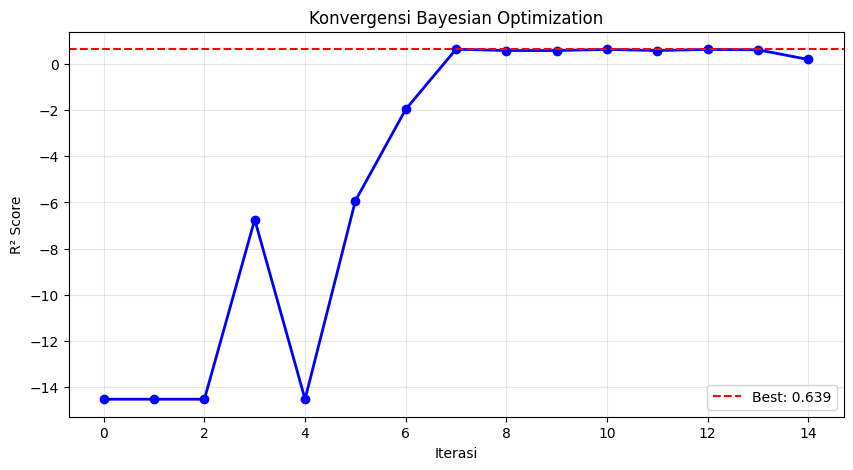

📊 Training ANFIS dengan 3360 data poin...
  Epoch 0: Loss = 3.9279
  Epoch 20: Loss = 0.0930
  Epoch 40: Loss = 0.0915
  Epoch 60: Loss = 0.0911
  Epoch 80: Loss = 0.1436
✅ Training selesai! Weights: [0.1 0.1 0.1 0.1], Bias: 4.13

📌 Step 5: Memulai optimasi prompt...
   ⏳ Proses ini memakan waktu ~5-10 menit...

🚀 OPTIMASI: Bruto, Tara, dan Neto
   Keyword: bruto, tara, neto, berat
   Varian per iterasi: 30
   Iterasi: 3
   Menggunakan Ollama: YES

[1] Generating outline...
   ✅ Outline: Pengertian, Bruto, Tara, Neto, Berat...
   ✅ Total Durasi: 13.0 menit

🔄 ITERASI 1/3

[2] Generating 30 prompt variants...
   ⏳ Proses generate memakan waktu ~3-5 menit...

📝 GENERATING 30 PROMPT VARIANTS
   Mode: Ollama
   Format: BAKU (Latar Belakang → Materi → Contoh → Latihan → Kesimpulan)
   Durasi: 5-10 menit

[1/30] Teori | standar 
   📝 [OLLAMA] Streaming response:  Title: Bruto, Tara, dan Neto: Pengertian dan Contoh Soal

Instruksi Prompt:

Dalam video materi pembelajaran Numerasi, akan dijela

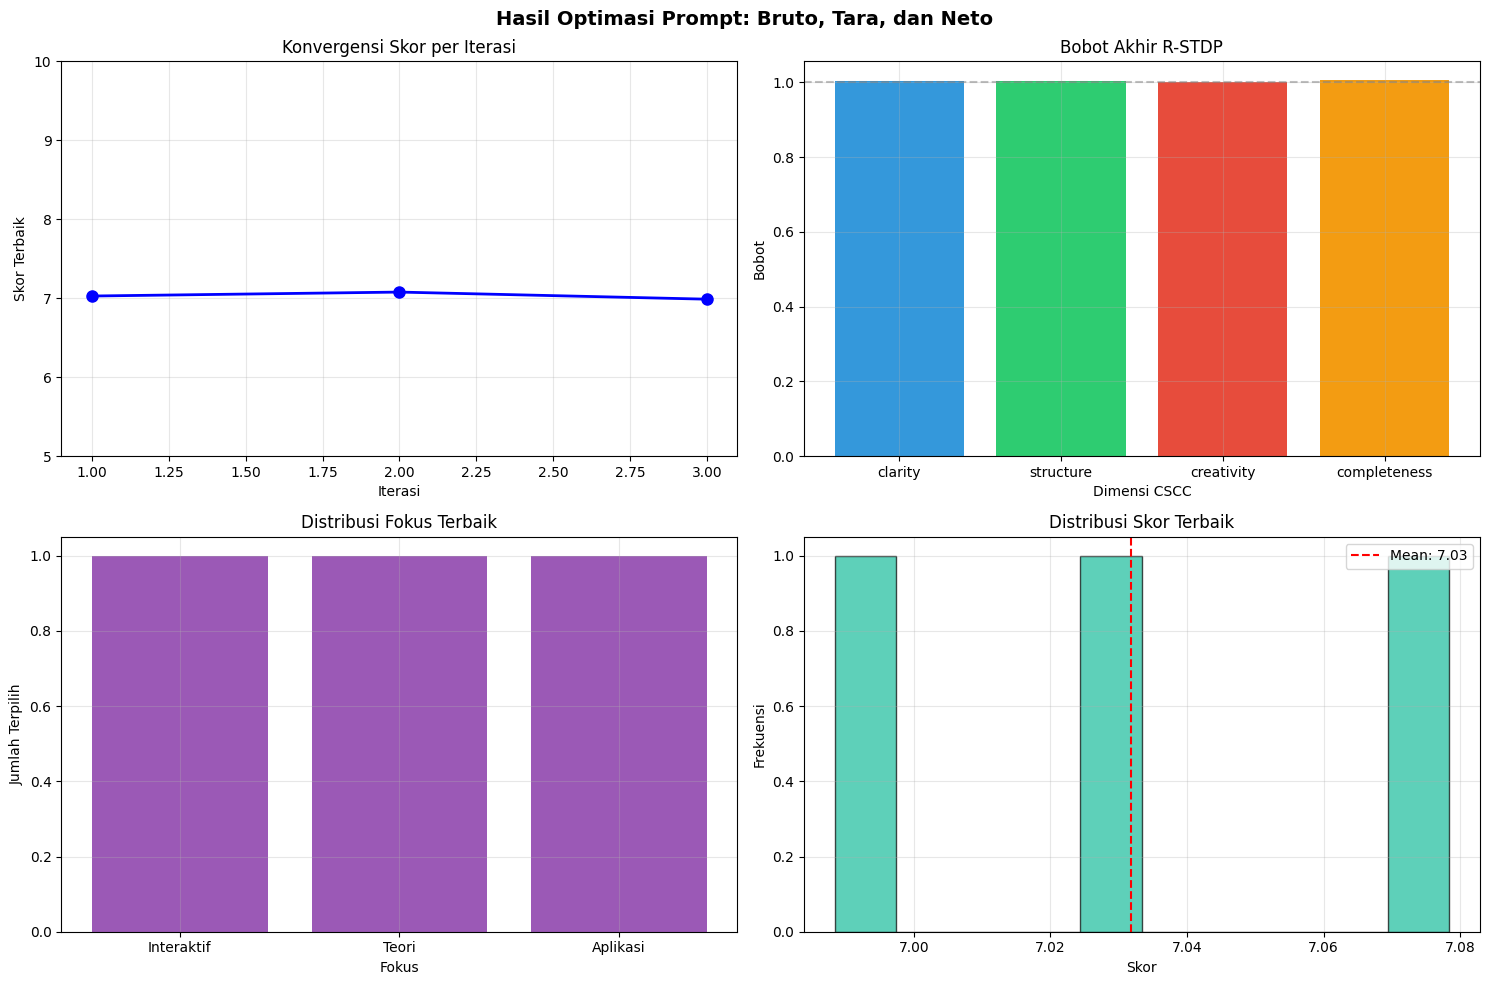

✅ Grafik disimpan!


In [ ]:
def display_topics():
    """Tampilkan daftar 32 topik."""
    print("\n" + "="*70)
    print("📋 DAFTAR SUBMATERI (32 TOPIK)")
    print("="*70)
    print(f"{'No':<4} {'Kategori':<12} {'Nama Topik':<45}")
    print("-"*70)

    for i, sm in enumerate(SUBMATERI_LIST, 1):
        kategori = "Literasi" if i <= 17 else "Numerasi"
        print(f"{i:<4} {kategori:<12} {sm['nama'][:45]:<45}")
    print("-"*70)

def select_topic():
    """Minta user memilih topik."""
    display_topics()

    while True:
        try:
            pilihan = int(input(f"\n🔹 Pilih nomor topik (1-{len(SUBMATERI_LIST)}): "))
            if 1 <= pilihan <= len(SUBMATERI_LIST):
                selected = SUBMATERI_LIST[pilihan - 1]
                print(f"\n✅ Topik terpilih: {selected['nama']}")
                print(f"   Keyword: {', '.join(selected['keyword'])}")
                return selected
            else:
                print(f"❌ Masukkan angka 1-{len(SUBMATERI_LIST)}!")
        except ValueError:
            print("❌ Masukkan angka yang valid!")

def main():
    print("="*70)
    print("🚀 SISTEM OPTIMASI PROMPT MULTI-KRITERIA - OPSI 2026")
    print("   Weighted_Linear_Regression + Adaptive Weight Tuning + Bayesian Optimization + Ollama")
    print("="*70)

    # STEP 1: Setup Ollama
    print("\n📌 Step 1: Setting up Ollama...")

    # Cek apakah Ollama sudah ready
    if is_ollama_ready():
        print("   ✅ Ollama already ready! (model found)")
        use_ollama = True
    else:
        print("   ⚠️ Ollama not ready. Setting up...")
        print("   ⏳ Proses setup memakan waktu ~2-3 menit...")

        # Setup Ollama (force_register=True akan verifikasi file existing)
        ollama_ready = setup_ollama(force_register=True, timeout=120)

        if ollama_ready:
            print("   ✅ Ollama setup successful!")
            use_ollama = True
        else:
            print("   ⚠️ Ollama setup failed! Using manual fallback.")
            use_ollama = False

    # STEP 2: Upload files (opsional)
    print("\n📌 Step 2: Upload data training...")
    uploaded_files = upload_files()
    data_files = load_uploaded_files(uploaded_files)

    # STEP 3: Prepare training data
    df_train = prepare_training_data(data_files)

    # STEP 4: Pilih topik
    print("\n📌 Step 3: Pilih topik...")
    selected_topic = select_topic()

    # STEP 5: Inisialisasi sistem
    print("\n📌 Step 4: Inisialisasi sistem...")
    print("   ⏳ Proses ini memakan waktu ~2-3 menit...")
    system = PromptOptimizationSystem(df_train, use_ollama=True)

    # STEP 6: Optimasi
    print("\n📌 Step 5: Memulai optimasi prompt...")
    print("   ⏳ Proses ini memakan waktu ~5-10 menit...")
    result = system.optimize(selected_topic, n_variants=30, n_iterations=3)

    # STEP 7: Output
    print("\n" + "="*70)
    print(f"📝 PROMPT TERBAIK: {selected_topic['nama']}")
    print("="*70)
    print(result['best_prompt'])

    # STEP 8: Simpan ke file
    filename = f"prompt_{selected_topic['nama'].replace(' ', '_').replace(':', '').replace('(', '').replace(')', '')}.txt"
    with open(filename, 'w', encoding='utf-8') as f:
        f.write(f"=== {selected_topic['nama']} ===\n")
        f.write(f"Skor: {result['best_score']:.2f}/10\n")
        f.write(f"Fokus: {result['best_fokus']}\n")
        f.write(f"Gaya: {result['best_gaya']}\n")
        f.write(f"Bayesian R²: {result['bayesian_r2']:.4f}\n")
        f.write("="*70 + "\n\n")
        f.write(result['best_prompt'])

    print(f"\n✅ Prompt disimpan ke '{filename}'")

    # STEP 9: Ringkasan
    print("\n" + "="*70)
    print("📊 RINGKASAN HASIL")
    print("="*70)
    print(f"  Topik: {selected_topic['nama']}")
    print(f"  Skor Terbaik: {result['best_score']:.2f}/10")
    print(f"  Fokus: {result['best_fokus']}")
    print(f"  Gaya: {result['best_gaya']}")
    print(f"  Iterasi: {len(result['iteration_history'])}")
    print(f"  Final Weights: {result['final_weights']}")
    print(f"  Bayesian Best R²: {result['bayesian_r2']:.4f}")
    print(f"  Bayesian Parameters: {result['bayesian_params']}")
    print("="*70)

    # STEP 10: Visualisasi
    visualize_results(result, selected_topic['nama'])

    return system, result

if __name__ == "__main__":
    system, result = main()